# work4 - A fair re-test of the battery fault model

This notebook re-checks the results from `work.ipynb`, `work2.ipynb` and `work3.ipynb`.

1. Dataset facts (cars, rows per car, labels)
2. What column 2 of the raw data ("temperature") really behaves like
3. The same models scored on the same test cars
4. Cross-validation across all 49 cars, with the cutoff chosen on validation cars only
5. A decision per car instead of per snippet
6. SHAP: what the model relies on

Set `REPEATS = 1` for a quick run (about 3 minutes on a laptop CPU). The slides use `REPEATS = 5`.

In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, f1_score

DATA = "../data/final_training_dataset.csv"
REPEATS = 5        # repeats of the 7-fold car split
OUTER, INNER = 7, 4
BLUE, ORANGE = "#2a78d6", "#eb6834"   # healthy, faulty

df = pd.read_csv(DATA)
print(df.shape, "| cars:", df["car"].nunique())

(176327, 11) | cars: 49


## 1. Dataset facts

In [ ]:
per_car = df.groupby("car").agg(rows=("label", "size"), label=("label", "first"),mileage_min=("mileage", "min"), mileage_max=("mileage", "max"))
print("Cars by label (0 healthy, 1 faulty):", per_car["label"].value_counts().to_dict())
print("Share of snippets from faulty cars: %.1f%%" % (100 * df["label"].mean()))
print("Rows per car: min %d, median %d, max %d" % (per_car["rows"].min(), per_car["rows"].median(), per_car["rows"].max()))
top5 = per_car["rows"].sort_values(ascending=False).head(5)
print("The 5 largest cars:", top5.to_dict())
print("They hold %.1f%% of all rows; all five are faulty: %s" % (100 * top5.sum() / len(df), bool((per_car.loc[top5.index, "label"] == 1).all())))
print("Rows above 110,000 km: %d, of which faulty: %.2f%%" % ((df["mileage"] > 110000).sum(), 100 * df.loc[df["mileage"] > 110000, "label"].mean()))
per_car.sort_values("rows", ascending=False).head(10)

Cars by label (0 healthy, 1 faulty): {0: 33, 1: 16}
Share of snippets from faulty cars: 56.2%
Rows per car: min 27, median 1754, max 16282
The 5 largest cars: {500: 16282, 510: 16152, 501: 16025, 521: 15349, 502: 10724}
They hold 42.3% of all rows; all five are faulty: True
Rows above 110,000 km: 23533, of which faulty: 99.85%


,rows,label,mileage_min,mileage_max
car,,,,
500,16282,1,11890.560,124780.128
510,16152,1,27.456,143600.160
501,16025,1,15243.360,202233.504
521,15349,1,7644.384,113874.816
502,10724,1,18078.720,212307.744
506,9439,0,15.840,74689.824
512,9077,0,59.136,67562.880
503,7436,0,206.976,81900.192
516,7130,0,30.624,83598.240


## 2. What is column 2?

In `prework.ipynb` I called column 2 of the raw matrix "temperature" (`avg_temp`, `max_temp`). These checks test that name.
A battery temperature should not be capped at exactly 100, should not track voltage almost perfectly, and should not rise only while charging current flows.
A state-of-charge percentage would do all three.

Range of max_temp: 0.0 to 100.0
Share of snippets where max_temp is exactly 100: 35.0%
Correlation avg_temp vs avg_cell_voltage: 0.968
Charging snippets where the value rises (max > mean): 97.8%
Idle snippets where the value stays flat (max == mean): 96.6%


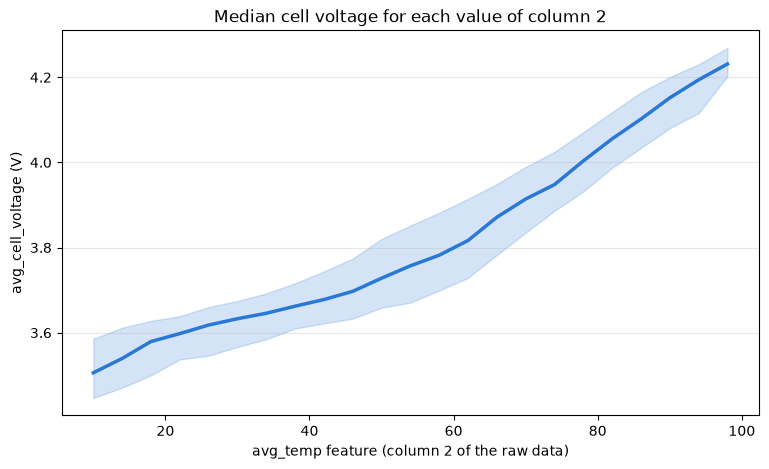

In [3]:
print("Range of max_temp: %.1f to %.1f" % (df["max_temp"].min(), df["max_temp"].max()))
print("Share of snippets where max_temp is exactly 100: %.1f%%" % (100 * (df["max_temp"] == 100).mean()))
print("Correlation avg_temp vs avg_cell_voltage: %.3f" % df["avg_temp"].corr(df["avg_cell_voltage"]))
charging = df[df["avg_current"] < -5]
idle = df[df["avg_current"].abs() < 0.5]
print("Charging snippets where the value rises (max > mean): %.1f%%" % (100 * (charging["max_temp"] > charging["avg_temp"] + 1e-9).mean()))
print("Idle snippets where the value stays flat (max == mean): %.1f%%" % (100 * np.isclose(idle["max_temp"], idle["avg_temp"]).mean()))

bins = pd.cut(df["avg_temp"], np.arange(8, 101, 4), include_lowest=True)
g = df.groupby(bins, observed=True)["avg_cell_voltage"]
x = [iv.mid for iv in g.median().index]
plt.figure(figsize=(9, 5))
plt.fill_between(x, g.quantile(0.1), g.quantile(0.9), color=BLUE, alpha=0.2)
plt.plot(x, g.median(), color=BLUE, linewidth=2.5)
plt.xlabel("avg_temp feature (column 2 of the raw data)"); plt.ylabel("avg_cell_voltage (V)")
plt.title("Median cell voltage for each value of column 2"); plt.grid(axis="y", alpha=0.3); plt.show()

The value never exceeds 100, sits at exactly 100 in about a third of snippets, climbs while the car is charging and stays flat when idle, and voltage rises smoothly with it from about 3.5 V to 4.23 V.
That is how a **state-of-charge percentage** behaves. The dataset's own column list should be checked to confirm, and the features renamed.

Also note that `voltage_gap` is the max minus the min of the *same* voltage column across the 128 time steps, so it is the voltage change during the snippet, not a gap between cells.

## 3. Feature engineering (same as work3) and helper functions

In [4]:
BASE7 = ["avg_cell_voltage", "max_cell_voltage", "min_cell_voltage", "avg_current", "avg_temp", "max_temp", "voltage_gap"]
ENG5 = ["rolling_max_temp_mean_10", "rolling_voltage_gap_mean_10", "rolling_voltage_gap_std_10", "thermal_load", "voltage_temp_ratio"]
TUNED = dict(learning_rate=0.1, max_depth=5, n_estimators=200, subsample=0.8, random_state=42, eval_metric="logloss")

def engineer_battery_features(df):
    d = df.copy().sort_values(by=["car", "mileage"]).reset_index(drop=True)
    g = d.groupby("car")
    d["rolling_max_temp_mean_10"] = g["max_temp"].transform(lambda x: x.rolling(10, min_periods=1).mean())
    d["rolling_voltage_gap_mean_10"] = g["voltage_gap"].transform(lambda x: x.rolling(10, min_periods=1).mean())
    d["rolling_voltage_gap_std_10"] = g["voltage_gap"].transform(lambda x: x.rolling(10, min_periods=1).std()).fillna(0)
    d["thermal_load"] = d["max_temp"] * np.abs(d["avg_current"])
    d["voltage_temp_ratio"] = d["voltage_gap"] / (d["max_temp"] + 1e-5)
    return d

def scores(y, pred):
    y = np.asarray(y); pred = np.asarray(pred).astype(int)
    tn = int(((y == 0) & (pred == 0)).sum()); fp = int(((y == 0) & (pred == 1)).sum())
    fn = int(((y == 1) & (pred == 0)).sum()); tp = int(((y == 1) & (pred == 1)).sum())
    n = tn + fp + fn + tp
    return dict(TN=tn, FP=fp, FN=fn, TP=tp, accuracy=(tn + tp) / n, recall=tp / max(tp + fn, 1),
                false_alarm=fp / max(tn + fp, 1), majority_guess=max(tn + fp, tp + fn) / n)

fe = engineer_battery_features(df)
y = fe["label"].values
cars = fe["car"].values

## 4. The same models on the same test cars

`work2` and `work3` both use `np.random.seed(42)` and pick 40 training cars, but `work3` sorts the table first, so the pick lands on different cars.
Here every model is scored on both sets of 9 test cars.

In [5]:
# test cars as work2 picked them (file order) and as work3 picked them (sorted order)
np.random.seed(42); all_cars = df["car"].unique()
test_A = sorted(set(all_cars) - set(np.random.choice(all_cars, size=40, replace=False)))
np.random.seed(42); all_cars = fe["car"].unique()
test_B = sorted(set(all_cars) - set(np.random.choice(all_cars, size=40, replace=False)))

rows = []
for set_name, test_cars in [("A (work2 cars)", test_A), ("B (work3 cars)", test_B)]:
    tr, te = fe[~fe["car"].isin(test_cars)], fe[fe["car"].isin(test_cars)]
    spw = (tr["label"] == 0).sum() / (tr["label"] == 1).sum()
    print(set_name, [int(c) for c in test_cars], "| rows:", len(te), "| faulty share: %.1f%%" % (100 * te["label"].mean()))
    for model_name, feats, params in [
        ("Model 3: 7 features + mileage, defaults", BASE7 + ["mileage"], dict(random_state=42)),
        ("7 features, defaults", BASE7, dict(random_state=42)),
        ("Final: 12 features, tuned, class weight", BASE7 + ENG5, dict(TUNED, scale_pos_weight=spw)),
    ]:
        p = xgb.XGBClassifier(**params).fit(tr[feats], tr["label"]).predict_proba(te[feats])[:, 1]
        for cutoff in (0.5, 0.10):
            rows.append(dict(test_cars=set_name, model=model_name, cutoff=cutoff, AUC=roc_auc_score(te["label"], p), **scores(te["label"], p >= cutoff)))
same_cars = pd.DataFrame(rows)
same_cars.round(3)

A (work2 cars) [505, 511, 518, 525, 529, 531, 533, 538, 549] | rows: 13263 | faulty share: 20.0%
B (work3 cars) [507, 514, 518, 520, 522, 528, 538, 542, 549] | rows: 16447 | faulty share: 68.0%


,test_cars,model,cutoff,AUC,TN,FP,FN,TP,accuracy,recall,false_alarm,majority_guess
0,A (work2 cars),"Model 3: 7 features + mileage, defaults",0.5,0.759,8177,2433,1252,1401,0.722,0.528,0.229,0.80
1,A (work2 cars),"Model 3: 7 features + mileage, defaults",0.1,0.759,6709,3901,386,2267,0.677,0.855,0.368,0.80
2,A (work2 cars),"7 features, defaults",0.5,0.817,7051,3559,515,2138,0.693,0.806,0.335,0.80
3,A (work2 cars),"7 features, defaults",0.1,0.817,3727,6883,45,2608,0.478,0.983,0.649,0.80
4,A (work2 cars),"Final: 12 features, tuned, class weight",0.5,0.825,7948,2662,701,1952,0.746,0.736,0.251,0.80
5,A (work2 cars),"Final: 12 features, tuned, class weight",0.1,0.825,3921,6689,34,2619,0.493,0.987,0.630,0.80
6,B (work3 cars),"Model 3: 7 features + mileage, defaults",0.5,0.972,5020,241,2010,9176,0.863,0.820,0.046,0.68
7,B (work3 cars),"Model 3: 7 features + mileage, defaults",0.1,0.972,4504,757,487,10699,0.924,0.956,0.144,0.68
8,B (work3 cars),"7 features, defaults",0.5,0.855,4319,942,3699,7487,0.718,0.669,0.179,0.68
9,B (work3 cars),"7 features, defaults",0.1,0.855,2771,2490,432,10754,0.822,0.961,0.473,0.68


## 5. Cross-validation across all 49 cars

- Cars are dealt into 7 folds (faulty and healthy cars separately, so every fold has both). Each fold takes a turn as the unseen test cars.
- Inside the training cars, a second grouped split gives out-of-fold predictions. The cutoff is chosen on those, with the same rule as `work3` (best F1 among cutoffs with recall of at least 0.75). The test cars are never used to choose it.
- The whole thing is repeated `REPEATS` times with different car shuffles.

In [6]:
CONFIGS = {
    "mileage only":               (["mileage"], False),
    "7 features":                 (BASE7, False),
    "7 features + mileage":       (BASE7 + ["mileage"], False),
    "12 features":                (BASE7 + ENG5, False),
    "12 features + class weight": (BASE7 + ENG5, True),
}
car_label = fe.groupby("car")["label"].first()

def car_folds(rep):
    rng = np.random.RandomState(100 + rep); fold_of = {}
    for lab in (1, 0):
        cs = car_label[car_label == lab].index.values.copy(); rng.shuffle(cs)
        for i, c in enumerate(cs):
            fold_of[c] = i % OUTER
    f = np.array([fold_of[c] for c in cars])
    for k in range(OUTER):
        yield np.where(f != k)[0], np.where(f == k)[0]

def fit_predict(Xtr, ytr, Xte, use_weight):
    params = dict(TUNED)
    if use_weight:
        params["scale_pos_weight"] = (ytr == 0).sum() / (ytr == 1).sum()
    return xgb.XGBClassifier(**params).fit(Xtr, ytr).predict_proba(Xte)[:, 1]

def pick_cutoff(y_val, p_val):
    best_t, best_f1 = 0.5, -1
    for t in np.round(np.arange(0.02, 0.92, 0.02), 2):
        pred = (p_val >= t).astype(int)
        if pred[y_val == 1].mean() >= 0.75:
            f1 = f1_score(y_val, pred, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
    return float(best_t)

def pick_car_cutoff(car_p, car_y):
    best_t, best_b = 0.5, -1
    for t in np.round(np.arange(0.10, 0.91, 0.01), 2):
        pred = car_p >= t
        b = (pred[car_y == 1].mean() + (~pred[car_y == 0]).mean()) / 2
        if b > best_b:
            best_b, best_t = b, t
    return float(best_t)

fold_rows, car_rows = [], []
for rep in range(REPEATS):
    for fold, (tr, te) in enumerate(car_folds(rep)):
        ytr, yte = y[tr], y[te]
        for name, (feats, use_weight) in CONFIGS.items():
            X = fe[feats].values
            p_val = np.zeros(len(tr))
            for itr, iva in GroupKFold(n_splits=INNER).split(X[tr], ytr, groups=cars[tr]):
                p_val[iva] = fit_predict(X[tr][itr], ytr[itr], X[tr][iva], use_weight)
            cutoff = pick_cutoff(ytr, p_val)
            p = fit_predict(X[tr], ytr, X[te], use_weight)
            for tag, t in [("0.50", 0.5), ("0.10", 0.10), ("validation", cutoff)]:
                fold_rows.append(dict(config=name, rep=rep, fold=fold, cutoff=tag, value=t, AUC=roc_auc_score(yte, p), **scores(yte, p >= t)))
            # one decision per car: average the snippet probabilities of each car
            train_cars = pd.DataFrame({"car": cars[tr], "p": p_val, "y": ytr}).groupby("car").agg(p=("p", "mean"), y=("y", "first"))
            t_car = pick_car_cutoff(train_cars["p"].values, train_cars["y"].values)
            test_cars = pd.DataFrame({"car": cars[te], "p": p, "y": yte, "flag": (p >= cutoff).astype(int)}).groupby("car").agg(
                mean_p=("p", "mean"), label=("y", "first"), rows=("p", "size"), share_flagged=("flag", "mean")).reset_index()
            test_cars["config"] = name; test_cars["rep"] = rep; test_cars["car_cutoff"] = t_car
            car_rows.append(test_cars)
    print("repeat", rep + 1, "of", REPEATS, "done")
folds = pd.DataFrame(fold_rows); car_results = pd.concat(car_rows, ignore_index=True)

repeat 1 of 5 done
repeat 2 of 5 done
repeat 3 of 5 done
repeat 4 of 5 done
repeat 5 of 5 done


In [7]:
folds["above_majority"] = folds["accuracy"] > folds["majority_guess"]
summary = folds.groupby(["config", "cutoff"]).agg(
    AUC=("AUC", "mean"), AUC_sd=("AUC", "std"),
    accuracy=("accuracy", "mean"), accuracy_sd=("accuracy", "std"),
    recall=("recall", "mean"), recall_sd=("recall", "std"),
    false_alarm=("false_alarm", "mean"), false_alarm_sd=("false_alarm", "std"),
    majority_guess=("majority_guess", "mean"), folds_above_majority=("above_majority", "sum"), folds=("above_majority", "size"),
    cutoff_value=("value", "mean"))
(summary * 100).round(1).assign(folds_above_majority=summary["folds_above_majority"], folds=summary["folds"], cutoff_value=summary["cutoff_value"].round(2))

AUC  AUC_sd  accuracy  accuracy_sd  \
config                     cutoff                                            
12 features                0.10        84.2     5.8      63.8         16.3   
                           0.50        84.2     5.8      76.5          5.0   
                           validation  84.2     5.8      74.4          7.4   
12 features + class weight 0.10        84.2     5.9      65.6         14.7   
                           0.50        84.2     5.9      77.6          4.8   
                           validation  84.2     5.9      74.4          7.7   
7 features                 0.10        83.9     5.7      64.0         16.2   
                           0.50        83.9     5.7      76.3          5.0   
                           validation  83.9     5.7      74.0          8.3   
7 features + mileage       0.10        86.1    12.4      71.1         15.4   
                           0.50        86.1    12.4      81.5          7.4   
                           validation  86.1    12.4      80.9          7.2   
mileage only               0.10        67.5    20.0      51.9         22.3   
                           0.50        67.5    20.0      59.9         10.5   
                           validation  67.5    20.0      55.5         20.7   

                                       recall  recall_sd  false_alarm  \
config                     cutoff                                       
12 features                0.10          96.0        5.9         70.0   
                           0.50          77.2        9.6         24.9   
                           validation    85.1        9.8         38.3   
12 features + class weight 0.10          95.4        6.1         66.6   
                           0.50          73.2       11.2         20.9   
                           validation    84.9        9.5         38.0   
7 features                 0.10          96.3        5.7         70.0   
                           0.50          76.6        9.1         25.3   
                           validation    85.6        8.9         40.1   
7 features + mileage       0.10          92.4       12.3         51.5   
                           0.50          75.2       16.6         15.6   
                           validation    74.5       18.5         17.7   
mileage only               0.10          94.2       13.3         92.1   
                           0.50          49.6       22.3         29.0   
                           validation    90.0       16.4         81.6   

                                       false_alarm_sd  majority_guess  \
config                     cutoff                                       
12 features                0.10                  10.4            69.4   
                           0.50                   7.8            69.4   
                           validation            11.8            69.4   
12 features + class weight 0.10                  11.0            69.4   
                           0.50                   7.3            69.4   
                           validation            12.0            69.4   
7 features                 0.10                   9.7            69.4   
                           0.50                   8.0            69.4   
                           validation            12.6            69.4   
7 features + mileage       0.10                  13.6            69.4   
                           0.50                  10.0            69.4   
                           validation            13.0            69.4   
mileage only               0.10                   6.2            69.4   
                           0.50                  17.0            69.4   
                           validation            12.6            69.4   

                                       folds_above_majority  folds  \
config                     cutoff                                    
12 features                0.10                          22     35   
                   

## 6. One decision per car

In [8]:
car_results["flagged"] = (car_results["mean_p"] >= car_results["car_cutoff"]).astype(int)
out = []
for (name, rep), d in car_results.groupby(["config", "rep"]):
    s = scores(d["label"], d["flagged"])
    out.append(dict(config=name, rep=rep, car_AUC=roc_auc_score(d["label"], d["mean_p"]),
                    faulty_caught=s["TP"], faulty_missed=s["FN"], healthy_flagged=s["FP"], healthy_cleared=s["TN"]))
car_summary = pd.DataFrame(out).groupby("config").mean(numeric_only=True).drop(columns="rep")
print("Average over repeats (16 faulty cars, 33 healthy cars):")
car_summary.round(2)

Average over repeats (16 faulty cars, 33 healthy cars):


,car_AUC,faulty_caught,faulty_missed,healthy_flagged,healthy_cleared
config,,,,,
12 features,0.94,13.4,2.6,6.4,26.6
12 features + class weight,0.94,13.4,2.6,5.6,27.4
7 features,0.94,13.8,2.2,6.4,26.6
7 features + mileage,0.96,13.4,2.6,1.6,31.4
mileage only,0.82,9.0,7.0,5.4,27.6


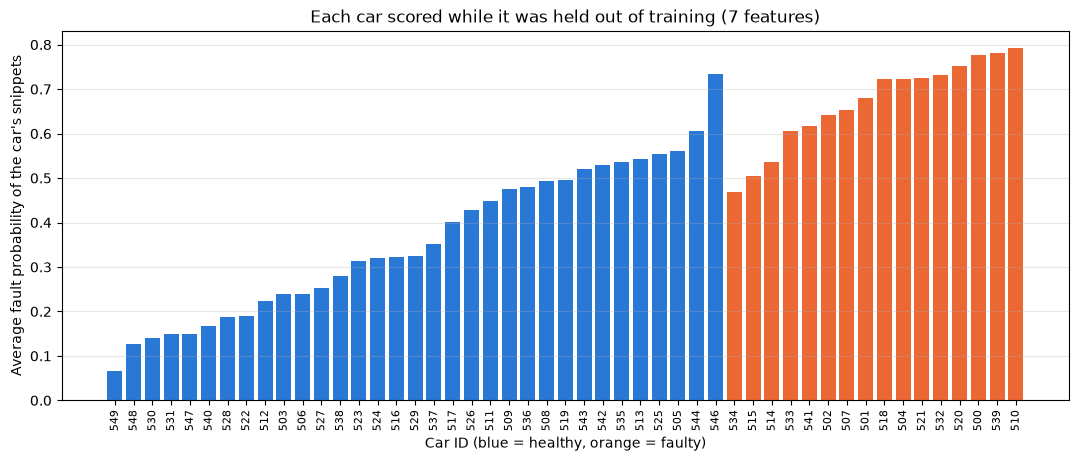

In [9]:
one = car_results[(car_results["config"] == "7 features") & (car_results["rep"] == 0)].sort_values(["label", "mean_p"]).reset_index(drop=True)
plt.figure(figsize=(13, 4.8))
plt.bar(range(len(one)), one["mean_p"], color=np.where(one["label"] == 1, ORANGE, BLUE))
plt.xticks(range(len(one)), one["car"].astype(int), rotation=90, fontsize=8)
plt.ylabel("Average fault probability of the car's snippets"); plt.xlabel("Car ID (blue = healthy, orange = faulty)")
plt.title("Each car scored while it was held out of training (7 features)"); plt.grid(axis="y", alpha=0.3); plt.show()

## 7. SHAP: what the model relies on

In [10]:
model = xgb.XGBClassifier(**TUNED).fit(fe[BASE7 + ENG5], fe["label"])
sample = fe.sample(n=30000, random_state=0)
contrib = model.get_booster().predict(xgb.DMatrix(sample[BASE7 + ENG5]), pred_contribs=True)[:, :-1]
shap_table = pd.DataFrame({
    "feature": BASE7 + ENG5,
    "mean_abs_shap": np.abs(contrib).mean(axis=0),
    "direction": [pd.Series(sample[f].values).corr(pd.Series(contrib[:, i]), method="spearman") for i, f in enumerate(BASE7 + ENG5)],
})
shap_table["share"] = shap_table["mean_abs_shap"] / shap_table["mean_abs_shap"].sum()
print("Share of total SHAP held by the 5 engineered features: %.1f%%" % (100 * shap_table[shap_table["feature"].isin(ENG5)]["share"].sum()))
shap_table.sort_values("mean_abs_shap", ascending=False).round(3)

Share of total SHAP held by the 5 engineered features: 31.3%


,feature,mean_abs_shap,direction,share
1,max_cell_voltage,0.582,-0.510,0.113
2,min_cell_voltage,0.580,-0.633,0.113
3,avg_current,0.563,0.450,0.110
4,avg_temp,0.548,0.706,0.107
0,avg_cell_voltage,0.544,-0.621,0.106
5,max_temp,0.455,0.863,0.089
10,thermal_load,0.398,0.737,0.078
8,rolling_voltage_gap_mean_10,0.383,0.792,0.075
7,rolling_max_temp_mean_10,0.361,0.905,0.070
11,voltage_temp_ratio,0.279,-0.056,0.054


`direction` is the rank correlation between a feature's value and its SHAP contribution: positive means higher values push the prediction towards "faulty".